# CFM — Round 2 : comparer sans se fier à la validation aléatoire, puis faire voter les voisins

Round 1 : blend SignatureNet **0,57** public, puis **0,5958** une fois équilibré. Mais la validation affichait 0,85 :
le split aléatoire mélange les fenêtres d'un même titre-jour. Ce notebook en tire les conséquences.

| § | Étape | Règle de décision, écrite avant de voir les résultats |
|---|---|---|
| 1 | Préparation | Réutilise le cache s'il existe dans `/kaggle/working/lab` |
| 2 | 6 configurations × 2 seeds | Classement par **précision stress après équilibrage**, moyennée sur les seeds. La validation est rapportée mais ne décide pas |
| 3 | Indicateurs sans labels sur le test | Ancrés aux deux scores connus (0,57 et 0,5958). Diagnostic seulement |
| 4 | Finalistes : 2 meilleures configs × 2 seeds, refit | — |
| 5 | Voisins : pureté puis grille de lissage sur valid ∪ stress | Lissage adopté seulement s'il gagne **≥ 0,5 pt** de précision équilibrée sur valid ∪ stress |
| 6 | Deux soumissions au plus | A = finalistes équilibrés ; B = A + lissage (si la règle est passée) |

⚠️ Équilibrage et lissage utilisent X_test sans labels (transductif). Ne les utiliser que si le règlement l'autorise.

In [1]:
import os, sys, json, subprocess
from pathlib import Path
if sys.platform == 'darwin':
    os.environ.setdefault('OMP_NUM_THREADS', '1')

CODE_DATASET = None   # ex. 'ton-username/cfm-signature-lab' ; None : code local ou Dataset attaché

def find_repo():
    if CODE_DATASET:
        import kagglehub
        path = Path(kagglehub.dataset_download(CODE_DATASET, force_download=True))
        hits = [p.parent.parent for p in path.glob('**/cfm/__init__.py')]
        if not hits:
            raise FileNotFoundError(f'{CODE_DATASET} ne contient pas cfm/')
        return hits[0]
    for p in [Path('.'), Path('..'), Path('/kaggle/working/cfm-signature-lab')]:
        if (p / 'cfm' / '__init__.py').exists():
            return p.resolve()
    for p in Path('/kaggle/input').glob('**/cfm/__init__.py'):
        return p.parent.parent
    raise FileNotFoundError('Code introuvable : renseigner CODE_DATASET ou attacher le Dataset du code')

REPO = find_repo(); sys.path.insert(0, str(REPO))
DEMO = True
SEEDS = [0, 1]
CONFIGS = {                      # nom de config → question posée (une différence à la fois)
    'signature':         'ancre : finaliste du round 1 (LB connu)',
    'signature_robust':  'ancre : finaliste du round 1 (LB connu)',
    'signature_no_bias': 'référence round 2 : signature sans biais même ordre (inutile au round 1)',
    'sig2_nolevels':     'sans tailles absolues : moins de piège de régime ?',
    'sig2_depthaug':     'profondeur ×exp(N(0,0.3)) : hypothèse « prix plus élevés »',
    'gru_wide':          'BiGRU à capacité égale (~332k) : design ou taille ?',
}
REFERENCE = 'signature_no_bias'
N_FINAL_CONFIGS = 2
MIN_SMOOTH_GAIN = 0.005

import numpy as np, pandas as pd
from cfm import config, io, split, blend, plots, proxies, transductive as T
from cfm.__main__ import prepare
from cfm.neural.train import fit, refit, embed
from cfm.metrics import scores
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 30)

LAB = 'demo_lab2' if DEMO else '/kaggle/working/lab'
DEMO_SET = ['neural.d_model=32', 'neural.heads=2', 'neural.train.epochs=3', 'neural.train.patience=3',
            'neural.train.batch_size=64', 'neural.train.amp=false'] if DEMO else []

def load_cfg(name='base', extra=()):
    over = [f'lab_dir={LAB}'] + (['device=cpu'] + DEMO_SET if DEMO else []) + list(extra)
    c = config.load(REPO / 'configs' / f'{name}.json', over)
    if DEMO and c['neural']['encoder'] == 'gru':
        c['neural']['d_model'] = 32
    return c

cfg = load_cfg()
print('repo', REPO, '| lab', LAB, '| device', cfg['device'])
print('code', next(l for l in (REPO / 'CHANGELOG.md').read_text().splitlines() if l.startswith('## ')))

repo <repo> | lab demo_lab2 | device cpu
code ## 0.1.2 — 2026-10-06


## 1. Préparation (cache réutilisé s'il existe)

In [2]:
files = None
if DEMO:
    from cfm.synthetic import create
    files = create('demo_data2')
sp = prepare(cfg, files)
print(json.loads((Path(LAB) / 'split.json').read_text())['sizes'])

[raw train] 480/480


[raw test] 144/144


tick report: {"tick": 0.01, "top_spreads": {"0.01": 25635, "0.02": 10420, "0.03": 6944, "0.04": 5001}, "price_off_grid": 0.0, "bid_off_grid": 0.0, "ask_off_grid": 0.0, "grid_ok": true}


[block tok_action/train] 1 columns, key 9f111197c7


[block tok_action/test] 1 columns, key 9f111197c7


...

[block tokens_bow/test] 24 columns, key 9b0338b034


[block transitions/train] 36 columns, key df4fa31bc7


[block transitions/test] 36 columns, key df4fa31bc7


split {'config': {'seed': 42, 'audit': 0.1, 'stress': 0.1, 'valid': 0.15, 'stress_tail': 'auto'}, 'tail_used': 'low', 'sizes': {'fit': 312, 'valid': 72, 'stress': 48, 'audit': 48}, 'transductive': True, 'median_log_depth': {'train': 2.890371799468994, 'test': 2.397895336151123}}


{'fit': 312, 'valid': 72, 'stress': 48, 'audit': 48}


## 2. Banc : 6 configurations × 2 seeds
Classement par précision **stress équilibrée** (moyenne des seeds). Au round 1, le stress a correctement prédit que l'équilibrage aiderait au LB.

In [3]:
results = {}
for name in CONFIGS:
    for seed in SEEDS:
        run = f'{name}_s{seed}'
        results[run] = fit(LAB, load_cfg(name, [f'neural.train.seed={seed}']), run, note=f'round 2 : {CONFIGS[name]}')

def balanced_stress(run):
    z = np.load(Path(LAB) / 'runs' / run / 'stress.npz')
    return scores(z['y'], blend.sinkhorn_balance(z['p']))['acc']

res = pd.DataFrame(results.values()).set_index('name')
res['stress_bal_acc'] = [balanced_stress(r) for r in res.index]
res['config'] = [r.rsplit('_s', 1)[0] for r in res.index]
per_run = res[['config', 'params', 'best_epoch', 'minutes', 'valid_acc', 'stress_acc', 'stress_bal_acc']]
display(per_run.round(4))
summary = res.groupby('config')[['valid_acc', 'stress_acc', 'stress_bal_acc', 'params', 'minutes']].agg(['mean', 'std'])
ref = summary.loc[REFERENCE, ('stress_bal_acc', 'mean')]
summary[('Δstress_bal_vs_ref', 'pts')] = (summary[('stress_bal_acc', 'mean')] - ref) * 100
summary = summary.sort_values(('stress_bal_acc', 'mean'), ascending=False)
summary.round(4)

[signature_s0] ep 01 loss 3.183 valid 0.0556 stress 0.0417 train(eval) 0.0609 (1.5s)


[signature_s0] ep 02 loss 3.163 valid 0.0694 stress 0.0625 train(eval) 0.0801 (1.2s)


[signature_s0] ep 03 loss 3.146 valid 0.0833 stress 0.0833 train(eval) 0.0801 (1.2s)


[signature_s0] best epoch 3 valid 0.0833 stress 0.0833 params 61,117


[signature_s1] ep 01 loss 3.181 valid 0.0417 stress 0.0417 train(eval) 0.0417 (1.2s)


...

[gru_wide_s1] ep 02 loss 3.161 valid 0.0417 stress 0.0625 train(eval) 0.0609 (1.5s)


[gru_wide_s1] ep 03 loss 3.148 valid 0.0556 stress 0.0625 train(eval) 0.0833 (1.6s)


[gru_wide_s1] best epoch 3 valid 0.0556 stress 0.0625 params 36,281


,config,params,best_epoch,minutes,valid_acc,stress_acc,stress_bal_acc
name,,,,,,,
signature_s0,signature,61117,3,0.1,0.0833,0.0833,0.2708
signature_s1,signature,61117,3,0.1,0.0417,0.0625,0.2917
signature_robust_s0,signature_robust,61117,3,0.1,0.0833,0.1042,0.2083
signature_robust_s1,signature_robust,61117,3,0.1,0.1111,0.1042,0.3125
signature_no_bias_s0,signature_no_bias,61113,3,0.1,0.0833,0.0833,0.2708
signature_no_bias_s1,signature_no_bias,61113,3,0.1,0.0417,0.0625,0.2917
sig2_nolevels_s0,sig2_nolevels,60121,3,0.1,0.0556,0.0417,0.2083
sig2_nolevels_s1,sig2_nolevels,60121,3,0.1,0.0833,0.0833,0.1458
sig2_depthaug_s0,sig2_depthaug,61113,3,0.2,0.1111,0.1250,0.2500


valid_acc         stress_acc         stress_bal_acc           params      minutes      Δstress_bal_vs_ref
                       mean     std       mean     std           mean     std     mean  std    mean  std                pts
config                                                                                                                     
gru_wide             0.0764  0.0295     0.0625  0.0000         0.3646  0.0147  36281.0  0.0     0.1  0.0             8.3333
signature            0.0625  0.0295     0.0729  0.0147         0.2812  0.0147  61117.0  0.0     0.1  0.0             0.0000
signature_no_bias    0.0625  0.0295     0.0729  0.0147         0.2812  0.0147  61113.0  0.0     0.1  0.0             0.0000
sig2_depthaug        0.0764  0.0491     0.0938  0.0442         0.2708  0.0295  61113.0  0.0     0.2  0.0            -1.0417
signature_robust     0.0972  0.0196     0.1042  0.0000         0.2604  0.0737  61117.0  0.0     0.1  0.0            -2.0833
sig2_nolevels        0.0694  0.0196     0.0625  0.0295         0.1771  0.0442  60121.0  0.0     0.1  0.0           -10.4167

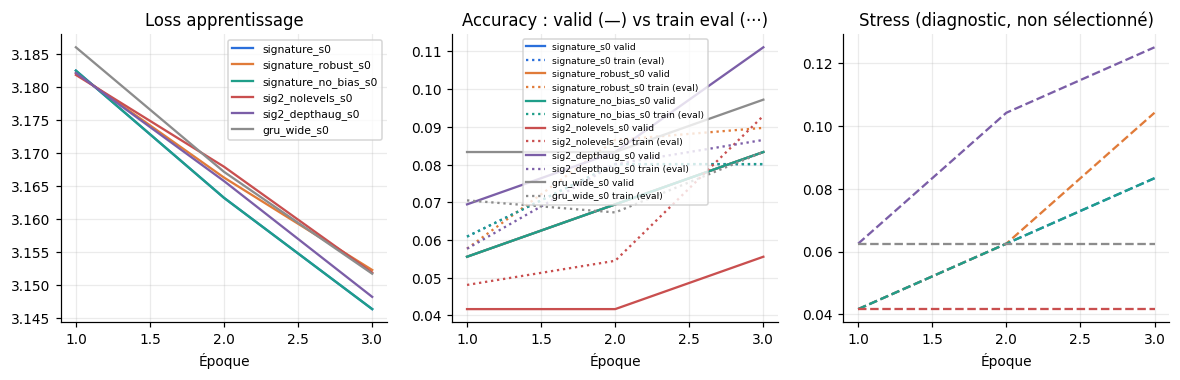

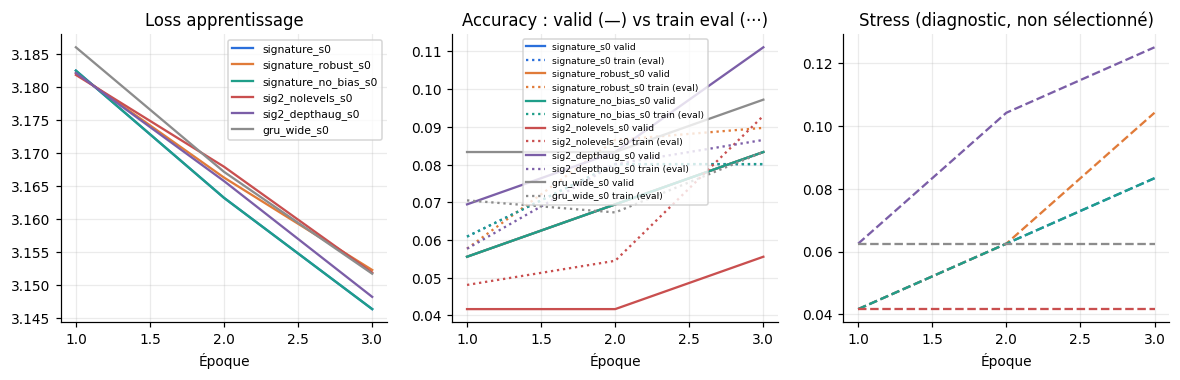

In [4]:
plots.histories(LAB, [f'{c}_s{SEEDS[0]}' for c in CONFIGS])

## 3. Indicateurs sans labels sur le test
Les ancres `signature_*` et `signature_robust_*` ont donné **0,57** (moyenne brute) et **0,5958** (équilibrée) au LB.
Un modèle qui garde une confiance et un accord entre seeds plus élevés sur le test, avec un `balance_kl` plus faible,
transfère probablement mieux. C'est un indice, pas une mesure.

In [5]:
prox = proxies.table(LAB, list(results))
prox['config'] = [r.rsplit('_s', 1)[0] for r in prox.index]
prox.groupby('config').mean(numeric_only=True).sort_values('stress_acc', ascending=False).round(3)

,test_confidence,test_entropy,test_balance_kl,test_max_min_ratio,stress_acc,stress_confidence,test_seed_agreement
config,,,,,,,
signature_robust,0.050,3.174,2.253,6.145833e+11,0.104,0.050,0.000
sig2_depthaug,0.051,3.174,2.447,7.256944e+11,0.094,0.051,0.000
signature_no_bias,0.051,3.174,2.640,7.951389e+11,0.073,0.051,0.000
signature,0.051,3.174,2.640,7.951389e+11,0.073,0.051,0.000
gru_wide,0.049,3.174,2.738,8.715278e+11,0.062,0.049,0.000
sig2_nolevels,0.050,3.173,2.417,6.909722e+11,0.062,0.050,0.021


## 4. Finalistes et refit

configs finalistes : ['gru_wide', 'signature'] → ['gru_wide_s0', 'gru_wide_s1', 'signature_s0', 'signature_s1']


[gru_wide_s0] ep 01 loss 3.182  (1.4s)


[gru_wide_s0] ep 02 loss 3.157  (1.2s)


[gru_wide_s0] ep 03 loss 3.131  (2.1s)


[gru_wide_s1] ep 01 loss 3.181  (1.5s)


...

[signature_s0] ep 03 loss 3.125  (3.3s)


[signature_s1] ep 01 loss 3.178  (2.8s)


[signature_s1] ep 02 loss 3.151  (2.8s)


[signature_s1] ep 03 loss 3.120  (3.9s)


,model,valid_acc,valid_logloss,stress_acc,stress_logloss
0,gru_wide_s0,0.097222,3.152109,0.062500,3.150063
1,gru_wide_s1,0.055556,3.139548,0.062500,3.143777
2,signature_s0,0.083333,3.145919,0.083333,3.144885
3,signature_s1,0.041667,3.140706,0.062500,3.141734
4,blend (mean),0.069444,3.141645,0.083333,3.142146
5,blend + balance,0.569444,3.140668,0.520833,3.141185


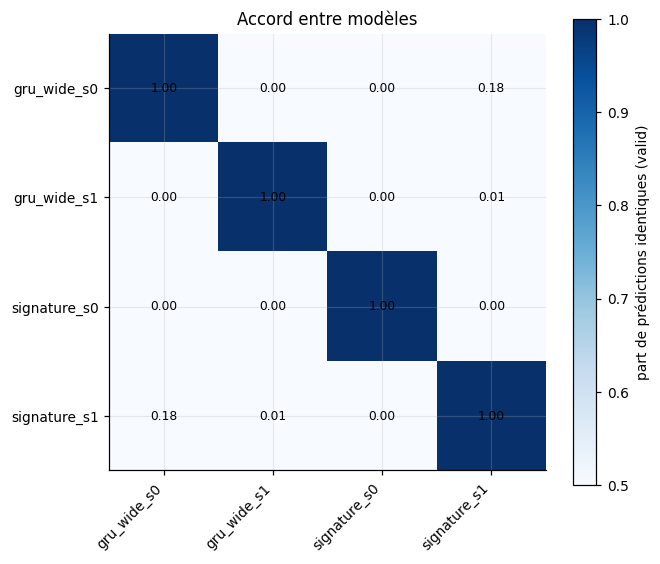

In [6]:
finals = list(summary.index[:N_FINAL_CONFIGS])
MEMBERS = [f'{c}_s{s}' for c in finals for s in SEEDS]
print('configs finalistes :', finals, '→', MEMBERS)
for m in MEMBERS:
    c = m.rsplit('_s', 1)[0]; s = int(m.rsplit('_s', 1)[1])
    refit(LAB, load_cfg(c, [f'neural.train.seed={s}']), m, 'epochs')
table, w, agree, oracle = blend.report(LAB, MEMBERS)
plots.agreement(agree, LAB)
table

## 5. Faire voter les voisins
1. **Pureté** : parmi les k plus proches voisins d'une fenêtre de valid ∪ stress, quelle part a le même titre ?
2. **Grille** : lissage des probabilités des modèles de développement, voisins cherchés dans valid ∪ stress seulement.
   C'est un score de **sélection**.
3. Le réglage choisi est appliqué au test avec `k × 4` : le test contient ~20 fenêtres par titre-jour contre ~5 dans le pool.

In [7]:
pool = np.r_[sp['valid'], sp['stress']]
y_pool = np.asarray(io.load(LAB, 'train')['y'])[pool].astype(int)
P_pool = np.mean([np.r_[np.load(Path(LAB) / 'runs' / m / 'valid.npz')['p'],
                        np.load(Path(LAB) / 'runs' / m / 'stress.npz')['p']] for m in MEMBERS], 0)
for m in MEMBERS:
    c = m.rsplit('_s', 1)[0]; s = int(m.rsplit('_s', 1)[1]); cm = load_cfg(c, [f'neural.train.seed={s}'])
    embed(LAB, cm, m, 'dev', ('valid', 'stress'))
    embed(LAB, cm, m, 'refit', ('test',))
Zv, _ = T.emb_rep(LAB, MEMBERS, 'dev', 'valid'); Zs, _ = T.emb_rep(LAB, MEMBERS, 'dev', 'stress')
reps_pool = {'window': T.window_rep(LAB, cfg, 'train', pool),
             'embedding': np.r_[Zv, Zs],
             'probs': np.sqrt(P_pool)}
pur = pd.DataFrame({k: T.purity(Z, y_pool) for k, Z in reps_pool.items()}).T
display(pur.round(3))
g = T.grid(P_pool, y_pool, reps_pool)
display(g.head(12).round(4))
best, none = g.iloc[0], g[g.rep == '(none)'].iloc[0]
USE_SMOOTHING = best.rep != '(none)' and best.acc_balanced >= none.acc_balanced + MIN_SMOOTH_GAIN
print(f"sans lissage {none.acc_balanced:.4f} | meilleur {best.rep} k={best.k} α={best.alpha} it={best.iters} "
      f"{best.acc_balanced:.4f} → lissage {'ADOPTÉ' if USE_SMOOTHING else 'rejeté'} (règle : +{MIN_SMOOTH_GAIN:.3f})")

,purity@5,purity@10,purity@20
window,0.485,0.322,0.185
embedding,0.352,0.261,0.162
probs,0.413,0.283,0.170


,rep,k,alpha,iters,acc,acc_balanced
9,window,5,0.5,1,0.0583,0.5667
27,embedding,3,0.5,1,0.0500,0.5667
1,window,3,0.3,1,0.0667,0.5667
26,embedding,3,0.3,5,0.0500,0.5667
25,embedding,3,0.3,1,0.0500,0.5667
33,embedding,5,0.5,1,0.0417,0.5583
2,window,3,0.3,5,0.0667,0.5583
3,window,3,0.5,1,0.0583,0.5500
7,window,5,0.3,1,0.0583,0.5500
28,embedding,3,0.5,5,0.0417,0.5500


sans lissage 0.5417 | meilleur window k=5 α=0.5 it=1 0.5667 → lissage ADOPTÉ (règle : +0.005)


## 6. Soumissions (deux au plus)

In [8]:
pathA = blend.submission(LAB, MEMBERS, None, source='test_refit', balance=True, name='submission_r2_balanced')
print('A :', pathA)
if USE_SMOOTHING:
    P_test = np.mean([np.load(Path(LAB) / 'runs' / m / 'test_refit.npz')['p'] for m in MEMBERS], 0)
    ids = np.asarray(io.load(LAB, 'test')['ids'])
    if best.rep == 'window':
        Z_test = T.window_rep(LAB, cfg, 'test', np.arange(len(ids)))
    elif best.rep == 'embedding':
        Z_test, eid = T.emb_rep(LAB, MEMBERS, 'refit', 'test'); assert np.array_equal(eid, ids)
    else:
        Z_test = np.sqrt(P_test)
    Q, kt = T.apply(P_test, Z_test, int(best.k), float(best.alpha), int(best.iters), k_scale=4)
    classes = np.asarray(io.meta(LAB)['classes'])
    pathB = Path(LAB) / 'submission_r2_balanced_knn.csv'
    pd.DataFrame({'obs_id': ids, 'eqt_code_cat': classes[Q.argmax(1)]}).to_csv(pathB, index=False)
    np.savez(Path(LAB) / 'submission_r2_balanced_knn_probs.npz', obs_ids=ids, p=Q)
    print('B :', pathB, f'(rep={best.rep}, k_test={kt}) — prédictions changées vs A : '
          f'{(Q.argmax(1) != pd.read_csv(pathA).eqt_code_cat.map({c: i for i, c in enumerate(classes)}).to_numpy()).mean():.1%}')

A : demo_lab2/submission_r2_balanced.csv


B : demo_lab2/submission_r2_balanced_knn.csv (rep=window, k_test=20) — prédictions changées vs A : 20.8%


In [9]:
import zipfile
dest = Path(LAB).parent / ('demo_results2.zip' if DEMO else 'lab_results_round2.zip')
with zipfile.ZipFile(dest, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in Path(LAB).rglob('*'):
        rel = p.relative_to(LAB)
        if p.is_file() and not {'raw', 'features'} & set(rel.parts) and p.suffix != '.pt' and not p.name.startswith('emb_'):
            z.write(p, rel)
print(dest, round(dest.stat().st_size / 1e6, 1), 'Mo')

demo_results2.zip 0.6 Mo
